<img src="Screenshot 2026-09-20 093049.png">
<img src='WhatsApp Image 2026-09-20 at 09.35.22 (1).jpeg'>
<img src='WhatsApp Image 2026-09-20 at 09.35.22.jpeg'>

In [2]:
from xgboost import XGBClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    recall_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
# Load Data set
# ===================================================================================
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names

class_names = data.target_names

print('Dataset shape: ', X.shape)

print(feature_names)
print(feature_names.shape)

print('Classes: ', class_names)


Dataset shape:  (569, 30)
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
(30,)
Classes:  ['malignant' 'benign']


In [4]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [5]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [6]:
# Check class Distribution
# ===================================================================================

print(pd.Series(y).value_counts())
pd.Series(y).value_counts(normalize=True) *100

1    357
0    212
Name: count, dtype: int64


1    62.741652
0    37.258348
Name: proportion, dtype: float64

In [7]:
# First: 70% train set and 30% tempory
# =========================================================================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Second: 50% evauation set and 50% test from temp set
# =========================================================================
X_val, X_test, y_val, y_test  =train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print('\nDataset splits:')
print('Training   :', X_train.shape)
print('Evaluation :', X_val.shape)
print('Testing    :', X_test.shape)


Dataset splits:
Training   : (398, 30)
Evaluation : (85, 30)
Testing    : (86, 30)


In [12]:
# Create XGBoost classifier
# =========================================================================

model = XGBClassifier(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=1000,
    eval_metric='logloss',
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=30,
    device='cuda'
)

<img src='Screenshot 2026-09-20 104041.png'>

<img src='Screenshot 2026-09-20 104424.png'>
<img src='Screenshot 2026-09-20 113418.png'>

## <b>colsample_bytree is set to select features randomly to reduce dominance of some features.</b><br>
## <b>early_stopping_rounds will control overfitting if the model wont improve significantly after given rounds.</b>

In [13]:
# Fit with BOTH train and validaton (this is what gives us clean curves)
# =======================================================================

model.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train), (X_val, y_val)],
    verbose = True
)

[0]	validation_0-logloss:0.61897	validation_1-logloss:0.62180
[1]	validation_0-logloss:0.58163	validation_1-logloss:0.58530
[2]	validation_0-logloss:0.54711	validation_1-logloss:0.55021
[3]	validation_0-logloss:0.51687	validation_1-logloss:0.52002
[4]	validation_0-logloss:0.48814	validation_1-logloss:0.49021
[5]	validation_0-logloss:0.46237	validation_1-logloss:0.46312
[6]	validation_0-logloss:0.43838	validation_1-logloss:0.43816
[7]	validation_0-logloss:0.41554	validation_1-logloss:0.41528
[8]	validation_0-logloss:0.39467	validation_1-logloss:0.39203
[9]	validation_0-logloss:0.37524	validation_1-logloss:0.37262
[10]	validation_0-logloss:0.35691	validation_1-logloss:0.35541
[11]	validation_0-logloss:0.34025	validation_1-logloss:0.33826
[12]	validation_0-logloss:0.32444	validation_1-logloss:0.32119
[13]	validation_0-logloss:0.30948	validation_1-logloss:0.30682
[14]	validation_0-logloss:0.29588	validation_1-logloss:0.29292
[15]	validation_0-logloss:0.28291	validation_1-logloss:0.27989
[1

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\callback.py:385: UserWarning: [12:33:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\callback.py:385: UserWarning: [12:33:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[123]	validation_0-logloss:0.02407	validation_1-logloss:0.03494
[124]	validation_0-logloss:0.02380	validation_1-logloss:0.03454
[125]	validation_0-logloss:0.02350	validation_1-logloss:0.03441
[126]	validation_0-logloss:0.02326	validation_1-logloss:0.03398
[127]	validation_0-logloss:0.02305	validation_1-logloss:0.03397
[128]	validation_0-logloss:0.02280	validation_1-logloss:0.03379
[129]	validation_0-logloss:0.02262	validation_1-logloss:0.03378
[130]	validation_0-logloss:0.02241	validation_1-logloss:0.03393
[131]	validation_0-logloss:0.02223	validation_1-logloss:0.03369
[132]	validation_0-logloss:0.02205	validation_1-logloss:0.03361
[133]	validation_0-logloss:0.02187	validation_1-logloss:0.03334
[134]	validation_0-logloss:0.02155	validation_1-logloss:0.03316
[135]	validation_0-logloss:0.02138	validation_1-logloss:0.03284
[136]	validation_0-logloss:0.02120	validation_1-logloss:0.03257
[137]	validation_0-logloss:0.02100	validation_1-logloss:0.03226
[138]	validation_0-logloss:0.02084	valid

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [14]:
results = model.evals_result()
print(results)

{'validation_0': OrderedDict({'logloss': [0.6189696758086957, 0.581634594193056, 0.5471148261023526, 0.5168666808898724, 0.48814191156296277, 0.46237280493106075, 0.43837682019226515, 0.41554124608411264, 0.39466879153670975, 0.3752442687450342, 0.3569102094850348, 0.34025064260516336, 0.32443966776432104, 0.30947822062813457, 0.2958805764365436, 0.28291107463327486, 0.2708673533333007, 0.2593678014736679, 0.24841692205050483, 0.23789502365804796, 0.22843099475356202, 0.21887563996428822, 0.21033697811203386, 0.20212611806901856, 0.19410007739037125, 0.1864628364617501, 0.17962257360019276, 0.1728206748264519, 0.16690299027229674, 0.16110406864677843, 0.15584620322339499, 0.1501681922406108, 0.144647828130117, 0.13995394975546016, 0.1350623299016725, 0.1307329948635856, 0.12606222536321263, 0.12193438363958843, 0.11776169215389831, 0.11419755030404682, 0.11122829173153369, 0.10761821071556466, 0.10482730189497447, 0.10141452963478002, 0.09821292928340447, 0.09523679576252574, 0.0924472

In [15]:
print(f'Best Iterstion: {model.best_iteration}')

Best Iterstion: 228


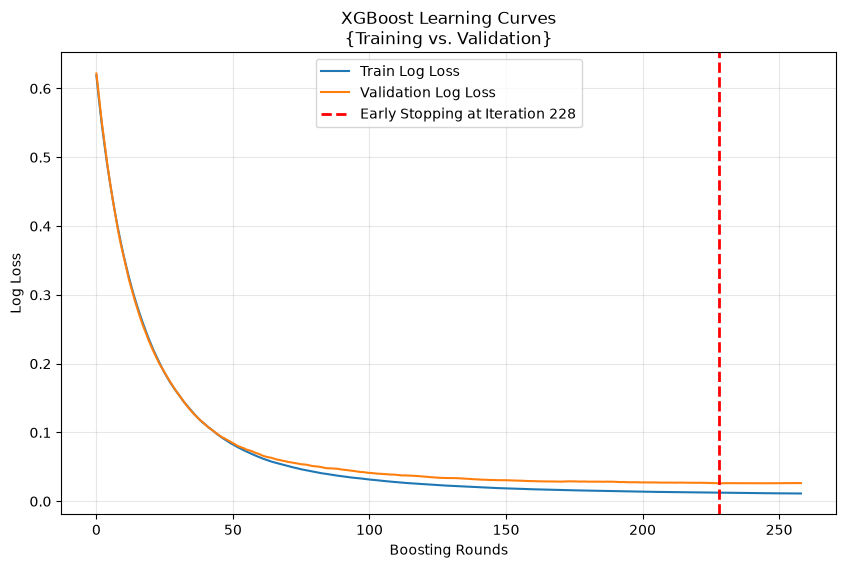

In [ ]:
# =============TRAINING / VALIDATION CURVES================================

plt.figure(figsize=(10,6))
plt.plot(results['validation_0']['logloss'], label='Train Log Loss')
plt.plot(results['validation_1']['logloss'], label='Validation Log Loss')

# Mark the point where early stopping kicked in
plt.axvline(
    x=model.best_iteration,
    color='red',
    ls='--',
    lw='2',
    label = f'Early Stopping at Iteration {model.best_iteration}'
)

plt.xlabel('Boosting Rounds')
plt.ylabel('Log Loss')
plt.title('XGBoost Learning Curves\n{Training vs. Validation}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
y_predict = model.predict(X_test)

print('Clasification Report on Test set:')
print(classification_report(y_test, y_predict, target_names=class_names))

Clasification Report on Test set:
              precision    recall  f1-score   support

   malignant       0.93      0.88      0.90        32
      benign       0.93      0.96      0.95        54

    accuracy                           0.93        86
   macro avg       0.93      0.92      0.92        86
weighted avg       0.93      0.93      0.93        86



In [23]:
model.save_model('breast_cancer_xgboost.json')

print('Model saved successfully...')

Model saved successfully...


In [24]:
loaded = XGBClassifier()
loaded.load_model('breast_cancer_xgboost.json')

In [25]:
print(X[1])
print(y[1])

[2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
 7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
 5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
 2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
 2.750e-01 8.902e-02]
0


In [27]:
loaded.predict(X[[1]])

array([0])